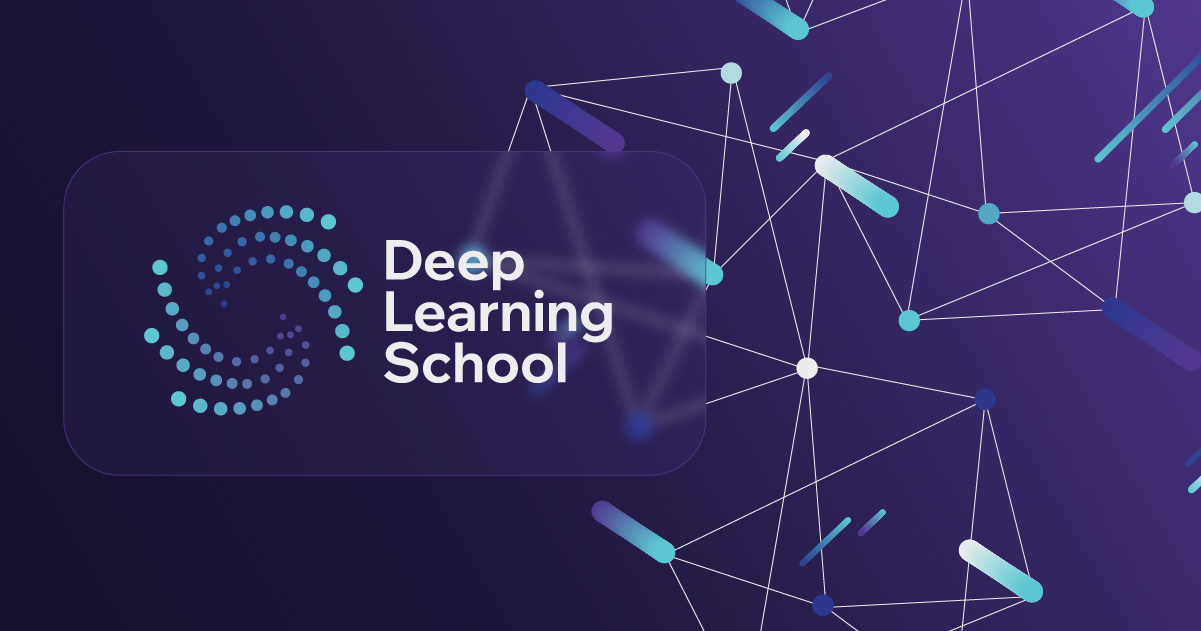

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Обучение языковой модели с помощью LSTM </b></h1>


В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [706]:
# !pip install datasets

Импорт необходимых библиотек

In [707]:
import random
import numpy as np
import torch
import os

# Фиксация всех источников случайности
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [708]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import math

import seaborn
seaborn.set_theme(palette='summer')

In [709]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\pong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [710]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [711]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [769]:
display(dataset['train']['text'][:7])

['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

In [713]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences

for sentence in tqdm(dataset['train']['text']):
    sentences.extend(
        [x.lower() for x in sent_tokenize(sentence) if len(word_tokenize(x.lower())) < word_threshold]
        )

  0%|          | 0/25000 [00:00<?, ?it/s]

In [714]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [715]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences):
    for word in word_tokenize(sentence):
        words[word] += 1

  0%|          | 0/198801 [00:00<?, ?it/s]

In [716]:
len(words)

68415

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set()
vocab_size = 40000

# Наполнение словаря

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])

# Топ слов (длиной vocab_size = 40000)
words_most_common = [word for word, _ in words.most_common(vocab_size)]
vocab.update(words_most_common)

In [718]:
len(vocab)

40004

In [719]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [720]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [721]:
word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

In [722]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        # Допишите код здесь
        tokenized_sentence += [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx])]
        tokenized_sentence += [self.eos_id]        

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [723]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [724]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возможные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader) -> float:

    model.eval()
    losses = []

    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, 
                batch['target_ids'].flatten()
            )
            losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    perplexity = math.exp(mean_loss)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [726]:
import pandas as pd

df_stats = pd.DataFrame(columns=['Model', 'Loss', 'Perplexity', 'Diff_Loss', 'Diff_Perplexity', 'Better_than_base'])

display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base


In [727]:
from IPython.display import clear_output

def train_model(model, criterion, optimizer, 
                model_name='Current',
                plot=True,
                num_epoch=35,
                base_losses=None,
                base_perplexities=None,
                train_loader=train_dataloader, 
                test_loader=eval_dataloader):
    
    # Напишите код здесь
    losses = []
    perplexities = []
    
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()

        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))

        # Отрисовка графиков
        if plot:

            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
            
            if model_name != 'GRU_Base_Model':
                axes[0].plot(base_losses[:epoch+1], color='b', marker='o', markersize=4, label='GRU_Base_Model')
            axes[0].plot(losses, color='r', marker='o', markersize=4, label=model_name)

            axes[0].set_title('Losses')
            axes[0].set_xlabel('epoch')
            axes[0].set_ylabel('loss')
            axes[0].grid(True)
            axes[0].legend()

            if model_name != 'GRU_Base_Model':
                axes[1].plot(base_perplexities[:epoch+1], color='b', marker='o', markersize=4, label='GRU_Base_Model')
            axes[1].plot(perplexities, color='r', marker='o', markersize=4, label=model_name)

            axes[1].set_title('Perplexities')
            axes[1].set_xlabel('epoch')
            axes[1].set_ylabel('perplexity')
            axes[1].grid(True)
            axes[1].legend()

            clear_output(wait=True)
            plt.show()

        # Заполнение таблицы
        curr_model_loss = min(losses)
        curr_model_perp = min(perplexities)
        if model_name != 'GRU_Base_Model':
            diff_loss = curr_model_loss - min(base_losses)
            diff_perp = curr_model_perp - min(base_perplexities)
        else:
            diff_loss = 0
            diff_perp = 0

        if model_name != 'GRU_Base_Model':
            better_than_base = curr_model_perp < min(base_perplexities)
        else:
            better_than_base = False
            
        data_to_add = (model_name, curr_model_loss, curr_model_perp, diff_loss, diff_perp, better_than_base)
        if model_name in df_stats['Model'].values:
            index = df_stats[df_stats['Model'] == model_name].index
        else:
            index = len(df_stats)
        df_stats.loc[index] = data_to_add

    print(f'Loss = {curr_model_loss}')
    print(f'Perplexity = {curr_model_perp}')

    # Сравнение текущей модели с базовой моделью
    if model_name != 'GRU_Base_Model':
        print('\nСравнение с GRU_Base_Model:')
        print('Loss', ('Хуже', 'Лучше')[curr_model_loss < min(base_losses)], 'на', abs(diff_loss))
        print('Perplexity', ('Хуже', 'Лучше')[curr_model_perp < min(base_perplexities)], 'на', abs(diff_perp))
    
    return losses, perplexities

### Base model

В качестве базовой модели возьмем модель из семинара. <br>
Результаты моделей из дальнейших экспериментов будем сравнивать с базовой моделью. <br>
Оценка того, какая из моделей лучше, будет основываться на метрике Perplexity.

In [728]:
class GRU_Base_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

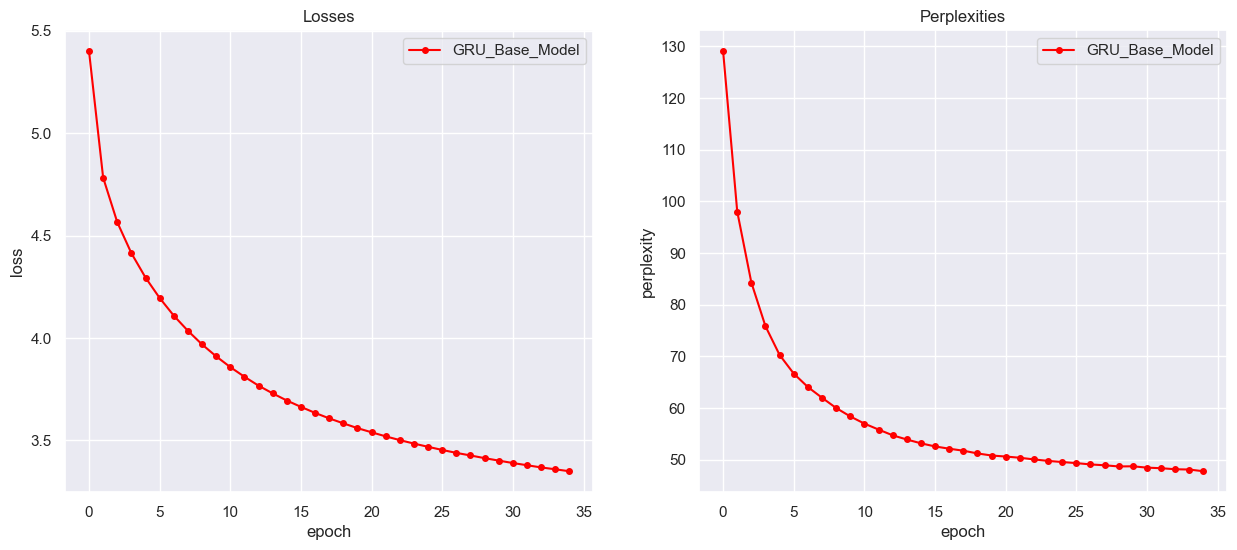

Loss = 3.3486153530863536
Perplexity = 47.7399529976823


In [729]:
model_name='GRU_Base_Model'

model = GRU_Base_LM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

base_losses, base_perplexities = train_model(model=model, 
                                             criterion=criterion, 
                                             optimizer=optimizer,
                                             model_name=model_name)

In [730]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0,0,False


### Замена GRU на LSTM (Первый эксперимент (2 балла))

Определите архитектуру модели и обучите её.

LSTM в отличии GRU лучше запоминает длинные зависимости.

In [731]:
class LSTM_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        
        return projection

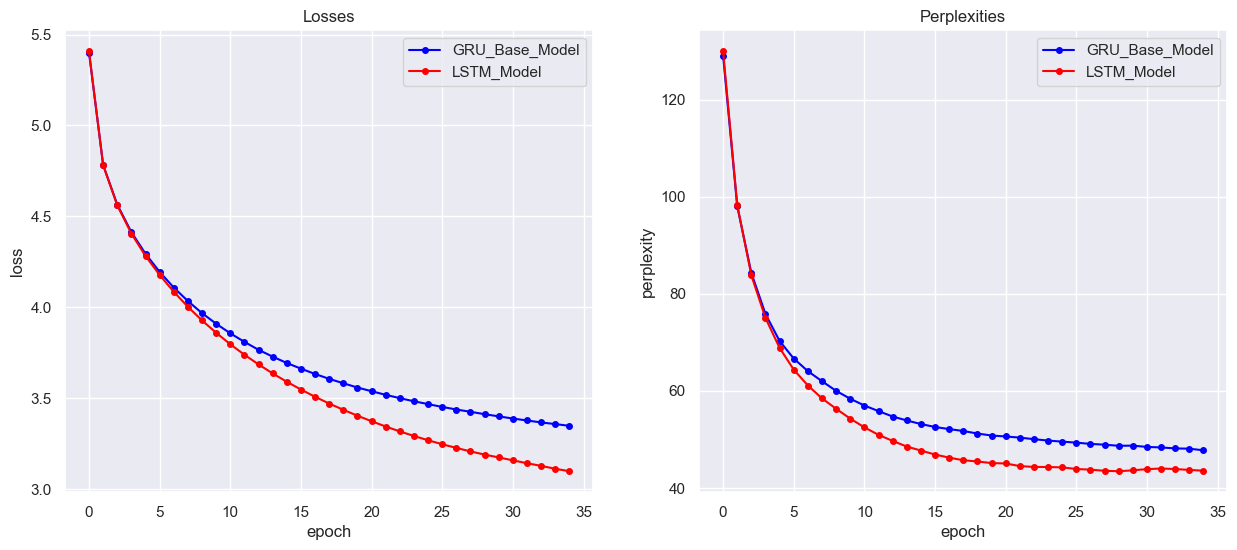

Loss = 3.0989123436106087
Perplexity = 43.42439667733452

Сравнение с GRU_Base_Model:
Loss Лучше на 0.24970300947574486
Perplexity Лучше на 4.315556320347781


In [732]:
model_name = 'LSTM_Model'

model = LSTM_LM(hidden_dim=256, vocab_size=len(vocab), num_layers=1).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

lstm_losses, lstm_perplexities = train_model(model=model, 
                                             criterion=criterion, 
                                             optimizer=optimizer,
                                             model_name=model_name,
                                             plot=True,
                                             num_epoch=35,
                                             base_losses=base_losses,
                                             base_perplexities=base_perplexities)

In [733]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True


### Использование сразу нескольких RNN блоков (Второй эксперимент (2 балла))

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Два блока RNN num_layers = 2. <br>
Позволит выделить более сложные иерархические зависимости.

In [734]:
class MultiLayerGRU_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.1)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        
        return projection

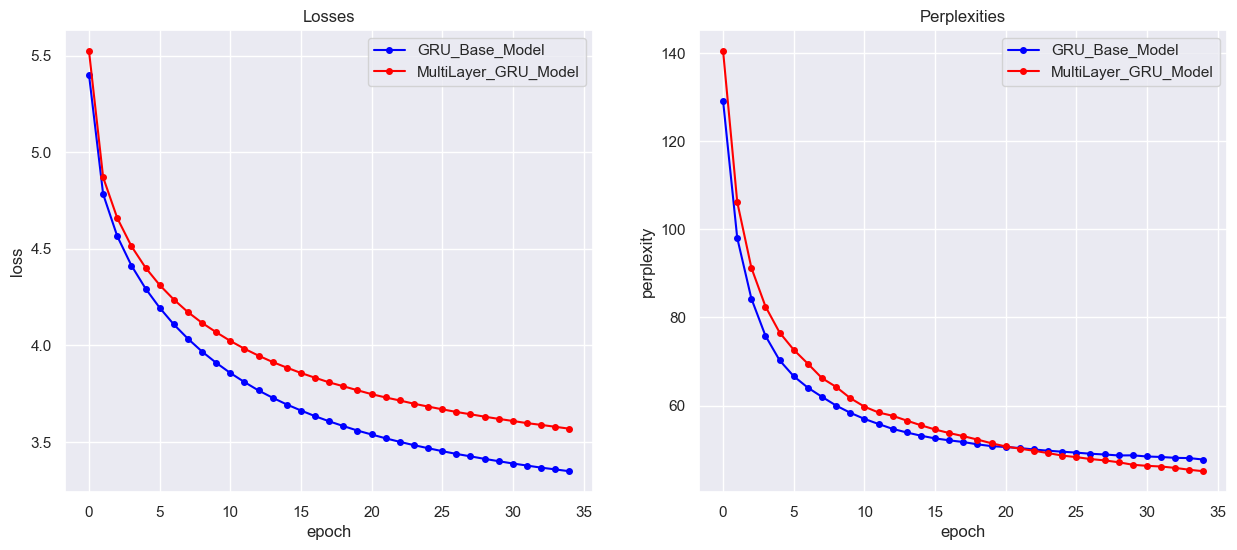

Loss = 3.5687269679212994
Perplexity = 45.088227082194905

Сравнение с GRU_Base_Model:
Loss Хуже на 0.2201116148349458
Perplexity Лучше на 2.651725915487397


In [735]:
model_name = 'MultiLayer_GRU_Model'

model = MultiLayerGRU_LM(hidden_dim=256, vocab_size=len(vocab), num_layers=2).to(device) # num_layers=2
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

multilayer_losses, multilayer_perplexities = train_model(model=model, 
                                                         criterion=criterion, 
                                                         optimizer=optimizer,
                                                         model_name=model_name,
                                                         plot=True,
                                                         num_epoch=35,
                                                         base_losses=base_losses,
                                                         base_perplexities=base_perplexities)

In [736]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True


Далее будут ещё эксперименты

### Увеличенние размера скрытого состояния

hidden_dim=512 позволит изучить более сложные закономерности.

In [737]:
class LargerHiddenDim_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        
        return projection

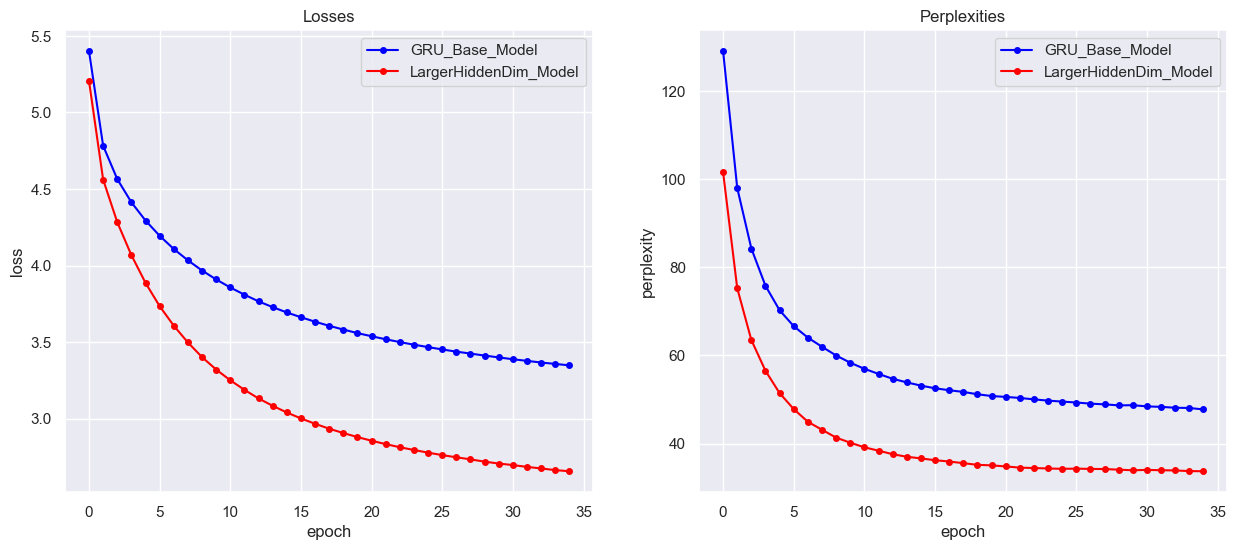

Loss = 2.65725870489211
Perplexity = 33.709729575689025

Сравнение с GRU_Base_Model:
Loss Лучше на 0.6913566481942435
Perplexity Лучше на 14.030223421993277


In [738]:
model_name = 'LargerHiddenDim_Model'

model = LargerHiddenDim_LM(hidden_dim=512, vocab_size=len(vocab)).to(device) # hidden_dim=512
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

larger_hidden_losses, larger_hidden_perplexities = train_model(model=model,
                                                               criterion=criterion,
                                                               optimizer=optimizer,
                                                               model_name=model_name,
                                                               plot=True,
                                                               num_epoch=35,
                                                               base_losses=base_losses,
                                                               base_perplexities=base_perplexities)

In [739]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True


### Увеличенние количества линейных слоёв после RNN

Модель с двумя линейными слоями. <br>
Теоретически позволит лучше распредлять вероятность следования слов.

In [740]:
class LargerLinearLayers_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        
        # Два линейных слоя
        self.linear_layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(p=0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(p=0.1)
        )
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.linear_layers(output)
        projection = self.projection(output)

        return projection

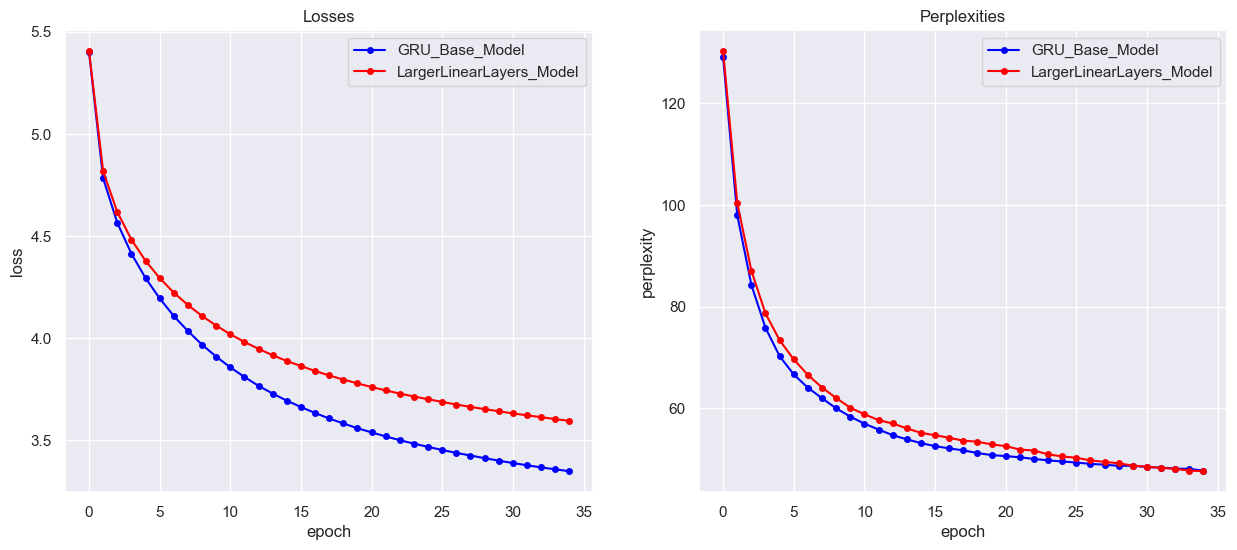

Loss = 3.595223607886538
Perplexity = 47.607385705066925

Сравнение с GRU_Base_Model:
Loss Хуже на 0.24660825480018422
Perplexity Лучше на 0.13256729261537714


In [741]:
model_name = 'LargerLinearLayers_Model'

model = LargerLinearLayers_LM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

larger_linear_losses, larger_linear_perplexities = train_model(model=model, 
                                                                criterion=criterion, 
                                                                optimizer=optimizer,
                                                                model_name=model_name,
                                                                plot=True,
                                                                num_epoch=35,
                                                                base_losses=base_losses,
                                                                base_perplexities=base_perplexities)

In [742]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True


### Использование альтернативной функции активации (GELU)

Применим функцию активации GELU вместо Tanh. <br>
Gaussian Error Linear Unit учитывает вероятностный характер нейронов.

In [743]:
class GELU_GRU_LM(nn.Module):

    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.GELU()    # GELU вместо Tanh
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

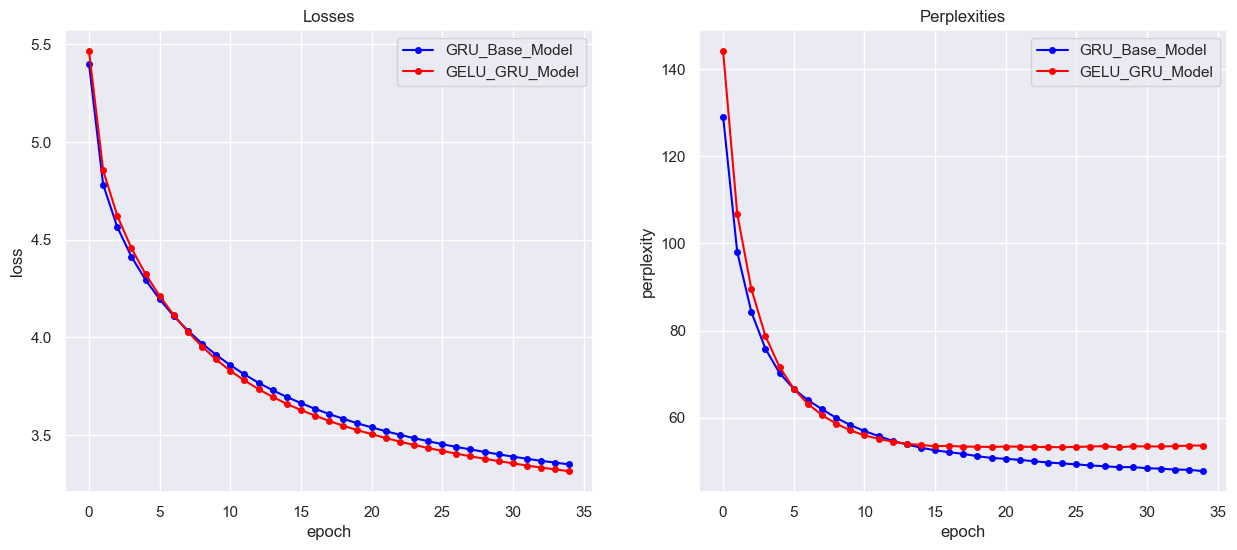

Loss = 3.3139008934806644
Perplexity = 53.21709448245683

Сравнение с GRU_Base_Model:
Loss Лучше на 0.034714459605689196
Perplexity Хуже на 5.477141484774528


In [744]:
model_name = 'GELU_GRU_Model'

model = GELU_GRU_LM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

gelu_losses, gelu_perplexities = train_model(model=model, 
                                              criterion=criterion, 
                                              optimizer=optimizer,
                                              model_name=model_name,
                                              plot=True,
                                              num_epoch=35,
                                              base_losses=base_losses,
                                              base_perplexities=base_perplexities)

In [745]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False


### Применение различных нормализаций

Увеличенние Dropout для регуляризации. <br>
Попробуем dropout = 0.3, тем самым уменьшим вероятность переобучения.

In [746]:
class LargerDropout_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, dropout_rate: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, dropout=dropout_rate)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

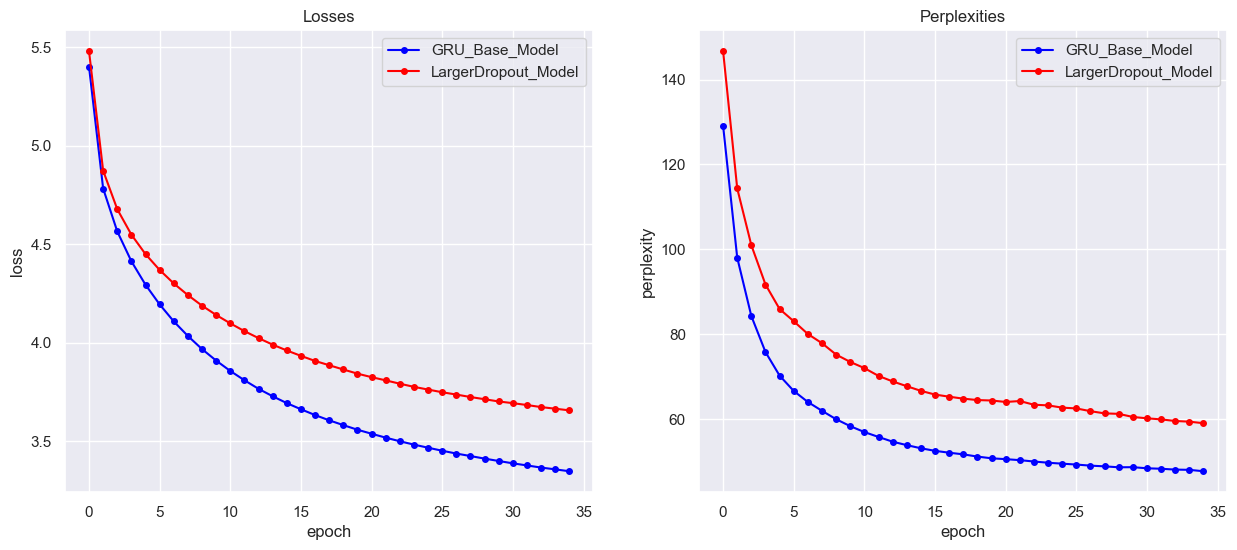

Loss = 3.6574581943014794
Perplexity = 59.0532194927761

Сравнение с GRU_Base_Model:
Loss Хуже на 0.30884284121512584
Perplexity Хуже на 11.3132664950938


In [747]:
model_name = 'LargerDropout_Model'

model = LargerDropout_LM(hidden_dim=256, vocab_size=len(vocab), dropout_rate=0.3).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

larger_dropout_losses, larger_dropout_perplexities = train_model(model=model, 
                                                              criterion=criterion, 
                                                              optimizer=optimizer,
                                                              model_name=model_name,
                                                              plot=True,
                                                              num_epoch=35,
                                                              base_losses=base_losses,
                                                              base_perplexities=base_perplexities)

In [748]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False
6,LargerDropout_Model,3.657458,59.053219,0.308843,11.313266,False


Добавление BatchNorm1d после RNN.

In [749]:
class BatchNorm_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)    # BatchNorm
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = output.transpose(1, 2)
        output = self.batch_norm(output)
        output = output.transpose(1, 2)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

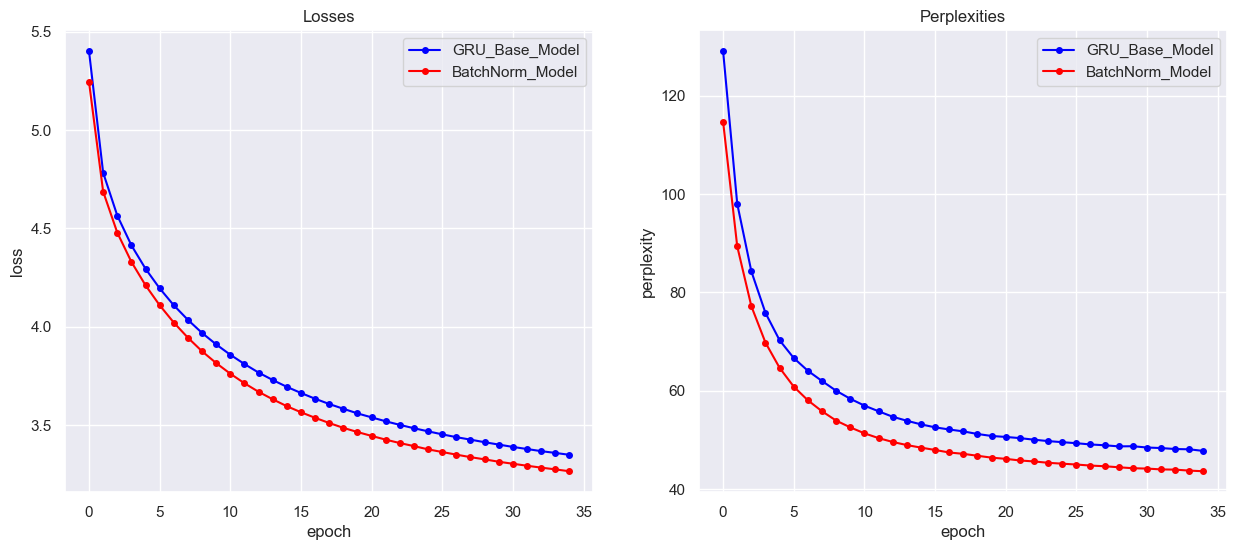

Loss = 3.2650455097373414
Perplexity = 43.608647857048105

Сравнение с GRU_Base_Model:
Loss Лучше на 0.08356984334901219
Perplexity Лучше на 4.131305140634197


In [750]:
model_name = 'BatchNorm_Model'

model = BatchNorm_LM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

batchnorm_losses, batchnorm_perplexities = train_model(model=model, 
                                                        criterion=criterion, 
                                                        optimizer=optimizer,
                                                        model_name=model_name,
                                                        plot=True,
                                                        num_epoch=35,
                                                        base_losses=base_losses,
                                                        base_perplexities=base_perplexities)

In [751]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False
6,LargerDropout_Model,3.657458,59.053219,0.308843,11.313266,False
7,BatchNorm_Model,3.265046,43.608648,-0.083570,-4.131305,True


Добавление LayerNorm после RNN. <br>
Предпочтительнее для моделей RNN, нежели BatchNorm.

In [752]:
class LayerNorm_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)  # LayerNorm
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.layer_norm(output)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

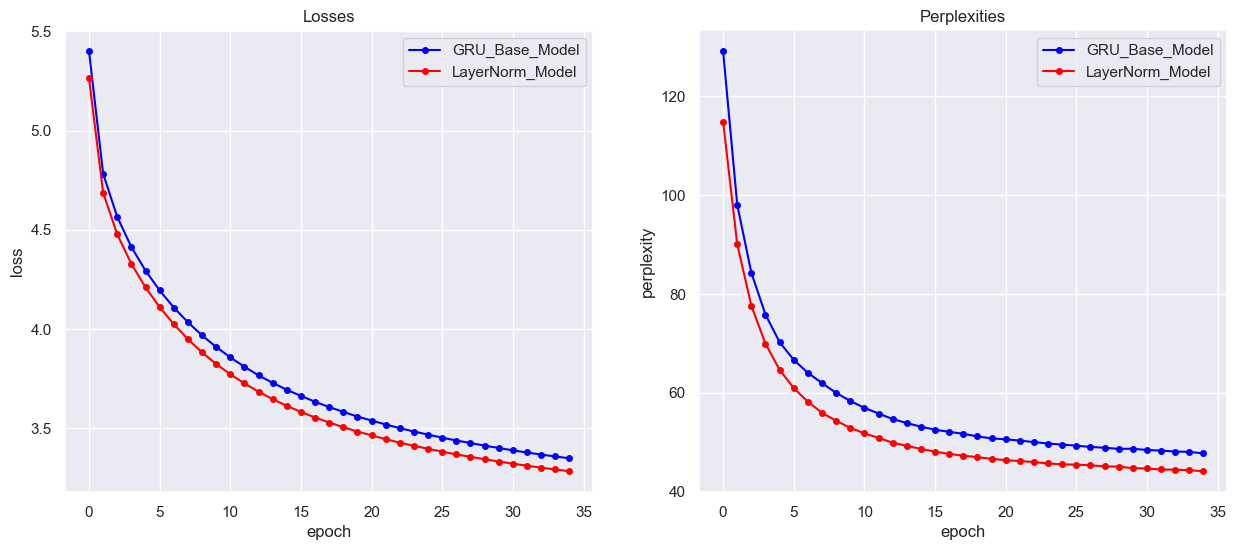

Loss = 3.2834822053594737
Perplexity = 44.143426833442824

Сравнение с GRU_Base_Model:
Loss Лучше на 0.06513314772687995
Perplexity Лучше на 3.596526164239478


In [753]:
model_name = 'LayerNorm_Model'

model = LayerNorm_LM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

layernorm_losses, layernorm_perplexities = train_model(model=model, 
                                                        criterion=criterion, 
                                                        optimizer=optimizer,
                                                        model_name=model_name,
                                                        plot=True,
                                                        num_epoch=35,
                                                        base_losses=base_losses,
                                                        base_perplexities=base_perplexities)

In [754]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False
6,LargerDropout_Model,3.657458,59.053219,0.308843,11.313266,False
7,BatchNorm_Model,3.265046,43.608648,-0.083570,-4.131305,True
8,LayerNorm_Model,3.283482,44.143427,-0.065133,-3.596526,True


### Увеличенние размера эмбеддингов

embedding_dim=512 для увеличения векотора предствления каждого слова. <br>
Для каждого слова кодируется больше информации.

In [755]:
class LargerEmbeddingDim_LM(nn.Module):
    def __init__(self, embedding_dim: int, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))
        
        return projection

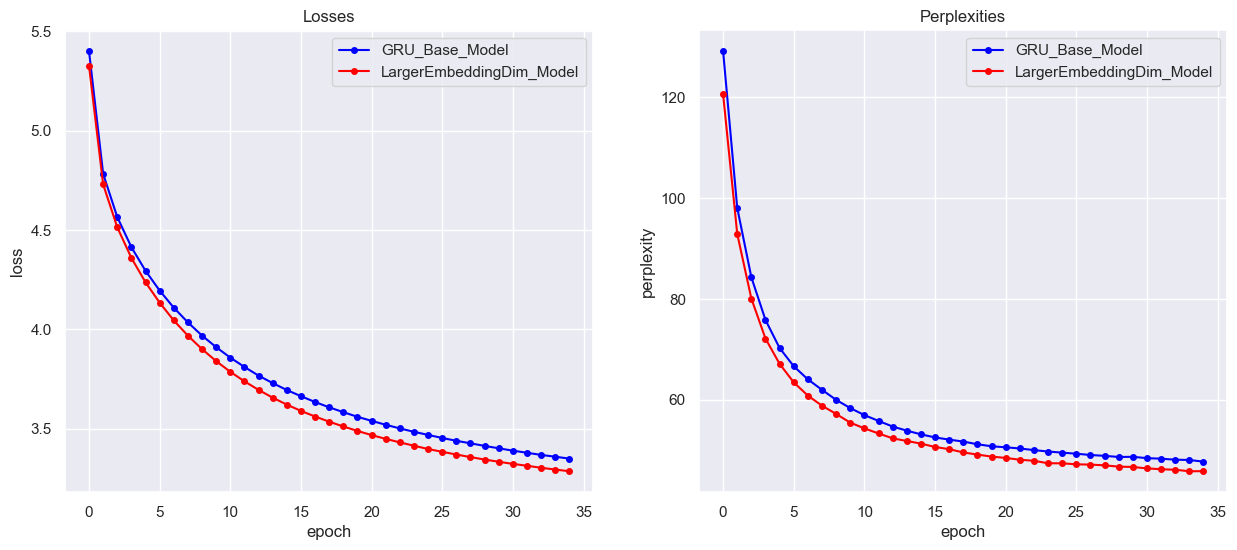

Loss = 3.285025845586726
Perplexity = 45.840118876754204

Сравнение с GRU_Base_Model:
Loss Лучше на 0.06358950749962755
Perplexity Лучше на 1.899834120928098


In [756]:
model_name = 'LargerEmbeddingDim_Model'

model = LargerEmbeddingDim_LM(embedding_dim=512, hidden_dim=256, vocab_size=len(vocab)).to(device) # embedding_dim=512
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

larger_emb_losses, larger_emb_perplexities = train_model(model=model, 
                                                          criterion=criterion, 
                                                          optimizer=optimizer,
                                                          model_name=model_name,
                                                          plot=True,
                                                          num_epoch=35,
                                                          base_losses=base_losses,
                                                          base_perplexities=base_perplexities)

In [757]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False
6,LargerDropout_Model,3.657458,59.053219,0.308843,11.313266,False
7,BatchNorm_Model,3.265046,43.608648,-0.083570,-4.131305,True
8,LayerNorm_Model,3.283482,44.143427,-0.065133,-3.596526,True
9,LargerEmbeddingDim_Model,3.285026,45.840119,-0.063590,-1.899834,True


### Финальная модель (комбинирование подходов)

Хорошо показали себя подходы:
- Замена GRU на LSTM
- Использование сразу нескольких RNN блоков
- Увеличение размера скрытого состояния
- Применения нормализаций BatchNom и LayerNorm <br>
(выберем LayerNorm, потому что данная нормализация является лучшей практикой для RNN моделей)

Применим подходы в финальной модели:

In [763]:
class Combined_LM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 1, dropout_rate: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        
        # self.batch_norm = nn.BatchNorm1d(hidden_dim)    # BatchNorm
        self.layer_norm = nn.LayerNorm(hidden_dim)      # LayerNorm

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_rate)
        
    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)

        # output = output.transpose(1, 2)    # BatchNorm
        # output = self.batch_norm(output)    # BatchNorm
        # output = output.transpose(1, 2)    # BatchNorm

        output = self.layer_norm(output)    # LayerNorm

        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

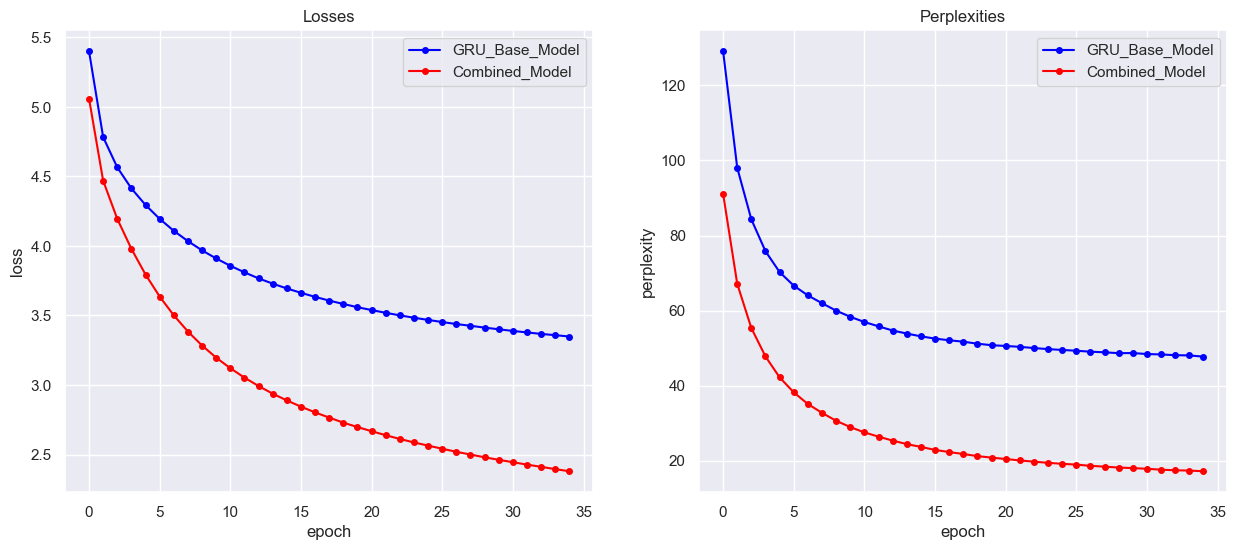

Loss = 2.379735365378118
Perplexity = 17.22332997258968

Сравнение с GRU_Base_Model:
Loss Лучше на 0.9688799877082355
Perplexity Лучше на 30.51662302509262


In [764]:
model_name = 'Combined_Model'

model = Combined_LM(hidden_dim=512, vocab_size=len(vocab), num_layers=2).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

combined_losses, combined_perplexities = train_model(model=model,
                                                     criterion=criterion, 
                                                     optimizer=optimizer,
                                                     model_name=model_name,
                                                     plot=True,
                                                     num_epoch=35,
                                                     base_losses=base_losses,
                                                     base_perplexities=base_perplexities)

In [765]:
display(df_stats)

,Model,Loss,Perplexity,Diff_Loss,Diff_Perplexity,Better_than_base
0,GRU_Base_Model,3.348615,47.739953,0.000000,0.000000,False
1,LSTM_Model,3.098912,43.424397,-0.249703,-4.315556,True
2,MultiLayer_GRU_Model,3.568727,45.088227,0.220112,-2.651726,True
3,LargerHiddenDim_Model,2.657259,33.709730,-0.691357,-14.030223,True
4,LargerLinearLayers_Model,3.595224,47.607386,0.246608,-0.132567,True
5,GELU_GRU_Model,3.313901,53.217094,-0.034714,5.477141,False
6,LargerDropout_Model,3.657458,59.053219,0.308843,11.313266,False
7,BatchNorm_Model,3.265046,43.608648,-0.083570,-4.131305,True
8,LayerNorm_Model,3.283482,44.143427,-0.065133,-3.596526,True
9,LargerEmbeddingDim_Model,3.285026,45.840119,-0.063590,-1.899834,True


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

Было реализовано:
- Базовая модель с одним GRU слоем. <br>
Все последующие реализации сравнивались с метриками данныой модели.
- Была опробована замена GRU слоя на LSTM слой. <br>
Модель показала значительно лучшие результаты. Модель борется с затухающими градиентами и лучше запоминает длинные зависимости.
- Использования двух GRU слоев. <br>
Заметно улучшение метрики Perplexity. Результат, возможно, будет лучше в связке с регуляризацями.
- Увеличение скрытого состояния с 256 до 512. <br>
Лучший результат. Модель смогла выучить более сложные зависимости.
- Добавление дополнительного линейного слоя и небольшим Dropout. <br>
Значение метрик хуже, чем в базовой модели.
- Замена функции активации Tanh на GELU. <br>
Значение метрик хуже, чем в базовой модели.
- Увеличение Dropout с 0.1 до 0.3. <br>
Значение метрик хуже, чем в базовой модели. Возможно, что модель недообучилась и необходим подбор оптимального значения Dropout.
- Добавлена Batch Normalization (нормализация активации по батчу). <br>
Значение метрик лучше, чем в базовой модели.
- Добавлена Layer Normalization (нормализация активации по каждому элементу батча). <br>
Значение метрик лучше, чем в базовой модели. Для RNN моделей предпочтительнее.
- Увеличение размерности эмбеддингов с 256 до 512. <br>
Значимого улучшения не последовало.

Реализация финальной модели Combined_Model, которая включает лучшие практики из числа проведенных экспериментов:
- Замена GRU слоя на LSTM слой
- Использования двух слоев RNN (два слоя LSTM)
- Использование размера скрытого слоя hidden_dim = 512
- Добавлена Layer Normalization

Модель показала лучшие значения метрики Perplexity (17.223330); <br>
Loss (2.379735) также оказался самым низким относительно Loss'a других моделей.

Предложения по улучшению:
- Подобрать оптимальный оптимизатор
- Подобрать оптимальные гиперпараметры
- Реализовать Early Stopping

# График сравнения всех моделей

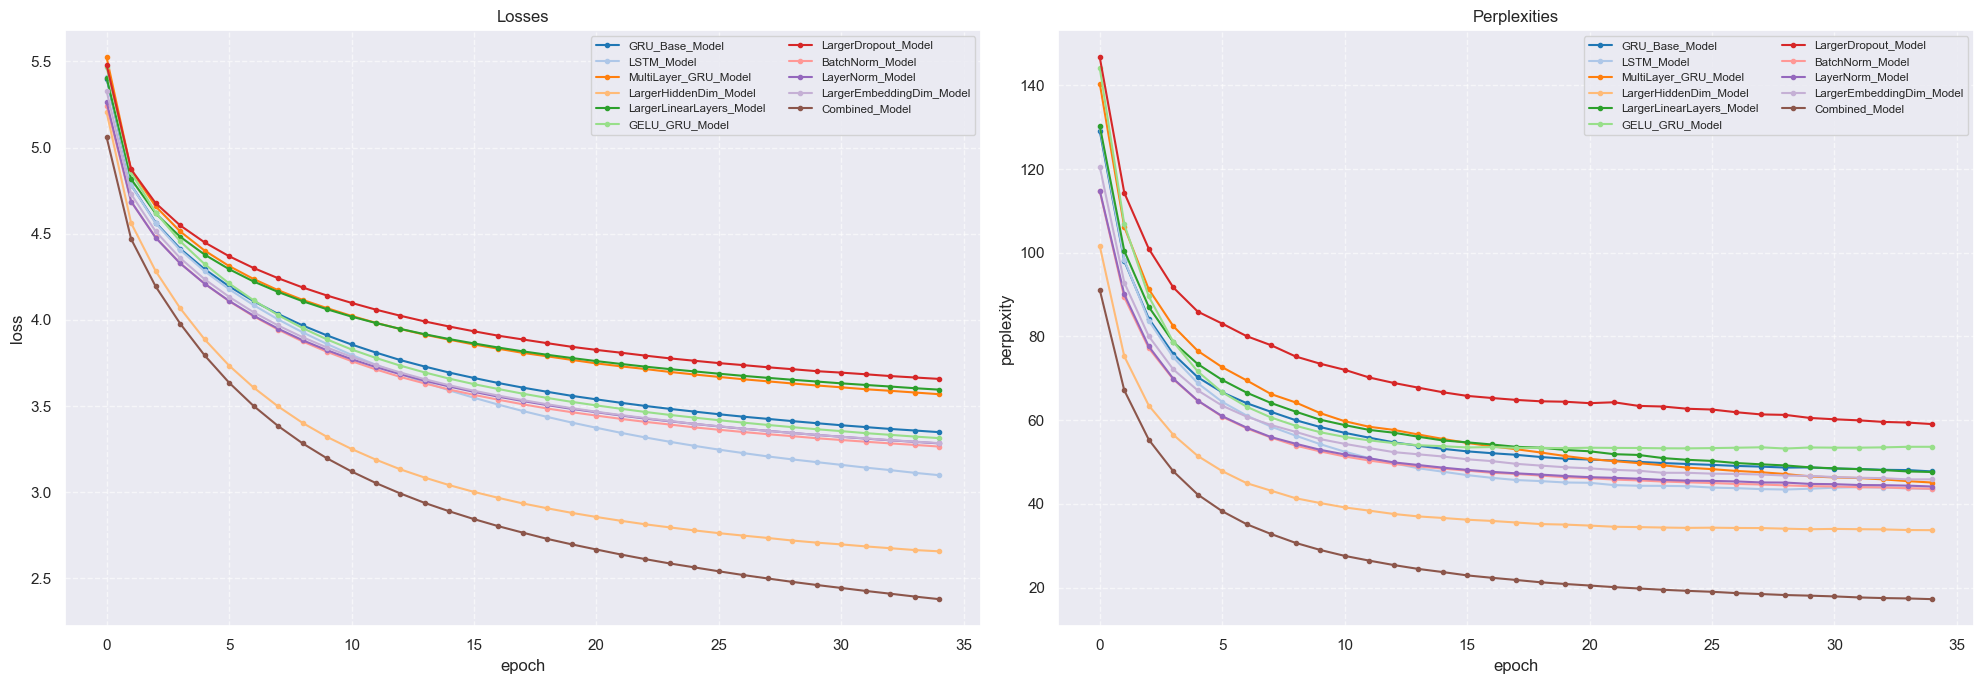

In [766]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

# Словарь со всеми моделями и полученными метриками
histories = {
    'GRU_Base_Model': (base_losses, base_perplexities),
    'LSTM_Model': (lstm_losses, lstm_perplexities),
    'MultiLayer_GRU_Model': (multilayer_losses, multilayer_perplexities),
    'LargerHiddenDim_Model': (larger_hidden_losses, larger_hidden_perplexities),
    'LargerLinearLayers_Model': (larger_linear_losses, larger_linear_perplexities),
    'GELU_GRU_Model': (gelu_losses, gelu_perplexities),
    'LargerDropout_Model': (larger_dropout_losses, larger_dropout_perplexities),
    'BatchNorm_Model': (batchnorm_losses, batchnorm_perplexities),
    'LayerNorm_Model': (layernorm_losses, layernorm_perplexities),
    'LargerEmbeddingDim_Model': (larger_emb_losses, larger_emb_perplexities),
    'Combined_Model': (combined_losses, combined_perplexities),
}

colors = plt.cm.tab20.colors

for i, (model_name, (losses, perplexities)) in enumerate(histories.items()):
    color = colors[i % len(colors)]
    
    axes[0].plot(losses, color=color, marker='o', markersize=3, linewidth=1.5, label=model_name)
    axes[1].plot(perplexities, color=color, marker='o', markersize=3, linewidth=1.5, label=model_name)

axes[0].set_title('Losses')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right', fontsize='x-small', ncol=2)

axes[1].set_title('Perplexities')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('perplexity')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right', fontsize='x-small', ncol=2)

plt.tight_layout()

plt.show();

Проверка на тесте

In [772]:
test_perplexity = evaluate(model, criterion, test_dataloader)

print(f'Perplexity на тесте: {test_perplexity}')

Perplexity на тесте: 17.3304825229429


Попробуем сгенерировать продолжение предложений

In [767]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 50) -> str:
    device = next(model.parameters()).device
    model.eval()
    
    # Разбиваем начальную строку на слова
    starting_words = starting_seq.strip().split()
    
    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in starting_words]
    input_ids = torch.LongTensor(input_ids).to(device)
    
    with torch.no_grad():
        for i in range(max_seq_len):
            output = model(input_ids.unsqueeze(0))
            next_word_distribution = output[0, -1, :]
            next_word = next_word_distribution.argmax()
            input_ids = torch.cat([input_ids, next_word.unsqueeze(0)])

            if next_word.item() == word2ind['<eos>']:
                break

    words = ' '.join([ind2word[idx.item()] for idx in input_ids[1:]
                      if ind2word[idx.item()] not in ['<pad>', '<unk>', '<eos>']])
    
    return words

In [777]:
generate_sequence(model, starting_seq='The filmmakers tried hard, but ')

"filmmakers tried but were n't much better ."

In [778]:
generate_sequence(model, starting_seq='never seen so many mistakes')

'never seen so many mistakes in this film .'

In [781]:
generate_sequence(model, starting_seq='this film')

'this film is a great movie .'